0. Przypomnij sobie, albo posłuchaj przypomnienia na wykładzie, czym jest wielowymiarowy
rozkład normalny.

1. Wygeneruj milion punktów z dwuwymiarowego rozkładu normalnego o średniej (0, 0) i iden-
tycznościowej macierzy kowariancji używając funkcji numpy.random.randn(...). Narysuj hi-
stogram takich danych (wskazówka: histogram będzie wykresem 3D).

In [97]:
import numpy as np
import matplotlib.pyplot as plt

In [98]:
n = 10**6

data = np.random.randn(n, 2)
x = data[:, 0]
y = data[:, 1]

In [99]:
hist, xedges, yedges = np.histogram2d(x, y, bins=30) # bins - klasycznie liczba kwadratów wzłuż osi (sumarycznie bins**2)
# hist - to tablica 2d wartości w każdym kwadracie
# xedges, yedges - to kolejne odpowiednio x'owe i y'owe krawędzie kwadratów

In [100]:
xpos, ypos = np.meshgrid( # współrzędne środka każdego kwadratu
    (xedges[:-1] + xedges[1:]) / 2, 
    (yedges[:-1] + yedges[1:]) / 2,
    indexing="ij"
)
print(xpos.shape, ypos.shape)

(30, 30) (30, 30)


In [101]:
xpos = xpos.ravel() # spłaszczamy do listy
ypos = ypos.ravel() # spłaszczamy do listy
zpos = np.zeros_like(xpos) # przygotowujemy liste wysokości
print(xpos.shape, ypos.shape, zpos.shape)

(900,) (900,) (900,)


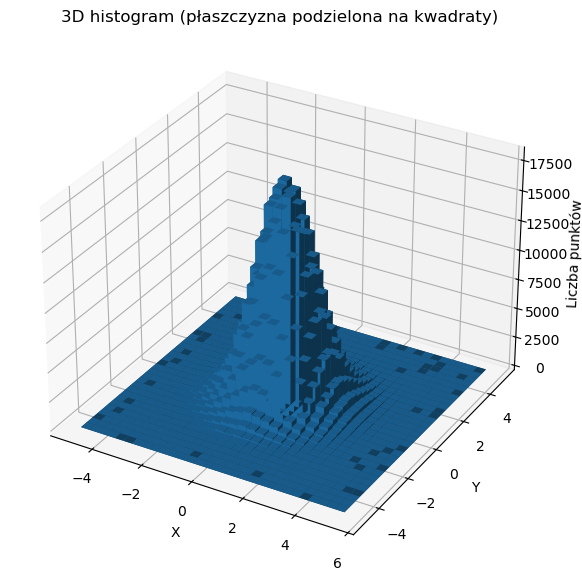

In [102]:
dz = hist.ravel() # odpowiednio wysokośc na kazdym słupków

dx = dy = (xedges[1] - xedges[0]) * np.ones_like(zpos) # szerokość każdego ze słupków

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(1,1,1, projection='3d')

ax.bar3d(xpos, ypos, zpos, dx, dy, dz)
# pozycje środków słupków (x, y), wysokości początku słupka (0!), szerokości słupków (x, y) wysokość słupków z
# 

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Liczba punktów')
ax.set_title('3D histogram (płaszczyzna podzielona na kwadraty)')

plt.show()

2. Na histogramie wygenerowanych danych narysuj funkcję gęstości rozkładu prawdopodobień-
stwa (wskazówka: wykres będzie 3D). Porównaj histogram z funkcją gęstości (wskazówka: wy-
godnie będzie zrobić wykres dynamiczny, umożliwiający obracanie i powiększanie, umożliwia

to na przykład pakiet plotly).

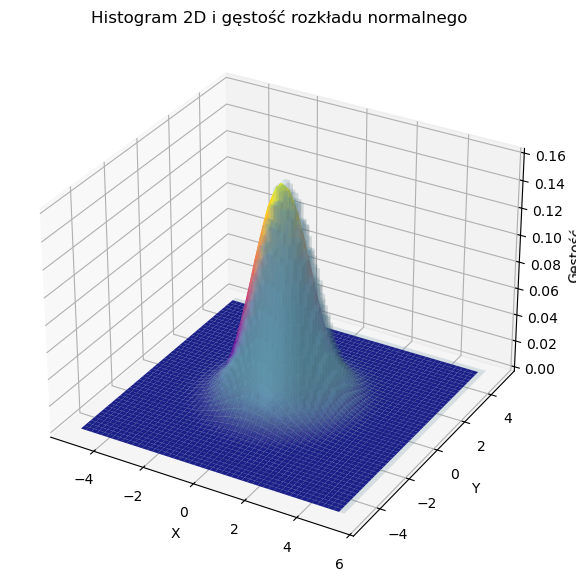

In [103]:
hist, xedges, yedges = np.histogram2d(x, y, bins=50, density=True)
X, Y = np.meshgrid(
    (xedges[:-1] + xedges[1:]) * 0.5,
    (yedges[:-1] + yedges[1:]) * 0.5,
    indexing="ij"
)
Z = (1/(2*np.pi)) * np.exp(-0.5 * (X**2 + Y**2))

xpos = X.ravel()
ypos = Y.ravel()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(1, 1, 1, projection='3d')

zpos = np.zeros_like(xpos)

dx = dy = (xedges[1] - xedges[0]) * np.ones_like(zpos)
dz = hist.ravel()

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, alpha=0.1, color='skyblue')

ax.plot_surface(X, Y, Z, alpha=1.0, cmap='plasma')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Gęstość')
ax.set_title("Histogram 2D i gęstość rozkładu normalnego")
plt.show()


Ruchoma opcja

In [104]:
import plotly.graph_objects as go

fig = go.Figure()

# Powierzchnia histogramu
fig.add_trace(go.Surface(
    z=hist.T, x=X, y=Y,
    colorscale="Blues",
    opacity=0.8,
    name="Histogram"
))

# Powierzchnia gęstości
fig.add_trace(go.Surface(
    z=Z, x=X, y=Y,
    colorscale="Plasma",
    opacity=0.8,
    name="Gęstość"
))

# Ustawienia osi i tytułu
fig.update_layout(
    title="Porównanie histogramu 2D i gęstości rozkładu normalnego",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Gęstość"
    ),
    width=900,
    height=700
)

fig.show()